## Load and parse the OpenSim '.sto' file


In [ ]:
import os
import opensim as osm
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

DATA_DIR = "/home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp"                       # for .npz files
STO_DIR  = "/home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp/fixed_elbowtest"        # for .sto files

SAVE_DIR = "/home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp/fixed_elbowtest"

MODEL_PATH = "/home/sydneyez/sydneyez/ProprioceptiveIllusions/MoBL-ARMSDynamicUpperLimb-latest/MoBL-ARMS Upper Extremity Model/Model/4.1/DefaultMOBL_ARMS_fixed_41.osim"
MOT_PATH = "/home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp/elbow_sweep_45to90_1s.mot"

model = osm.Model(MODEL_PATH)
state = model.initSystem()

def load_sto(path):
    """Parse an OpenSim .sto file into a pandas DataFrame."""
    with open(path) as f:
        lines = f.readlines()
    header_end = next(i for i, l in enumerate(lines) if l.strip() == "endheader")
    df = pd.read_csv(path, sep="\t", skiprows=header_end + 1)
    df.columns = [c.strip() for c in df.columns]
    return df

bk = load_sto(os.path.join(STO_DIR, "Right_BodyKinematics_pos_global.sto"))
bk.head()

[info] Loaded model Right from file /home/sydneyez/sydneyez/ProprioceptiveIllusions/MoBL-ARMSDynamicUpperLimb-latest/MoBL-ARMS Upper Extremity Model/Model/4.1/DefaultMOBL_ARMS_fixed_41.osim
[warning] Couldn't find file 'thorax.vtp'.
[warning] Couldn't find file 'clavicle.vtp'.
[warning] Couldn't find file 'scapula.vtp'.
[warning] Couldn't find file 'humerus.vtp'.
[warning] Couldn't find file 'ulna.vtp'.
[warning] Couldn't find file 'radius.vtp'.
[warning] Couldn't find file 'lunate.vtp'.
[warning] Couldn't find file 'sdfastSCAPHOIDw.vtp'.
[warning] Couldn't find file 'sdfastPISIFORMw.vtp'.
[warning] Couldn't find file 'sdfastTRIQUETRALw.vtp'.
[warning] Couldn't find file 'sdfast_1seg_hand_fr_c_5mc.vtp'.
[warning] Couldn't find file 'sdfast_1seg_hand_fr_c_4mc.vtp'.
[warning] Couldn't find file 'sdfast_1seg_hand_fr_c_3mc.vtp'.
[warning] Couldn't find file 'sdfast_1seg_hand_fr_c_2mc.vtp'.
[warning] Couldn't find file 'sdfast_1seg_hand_fr_c_trapezium.vtp'.
[warning] Couldn't find file 'sdf

,time,clavicle_X,clavicle_Y,clavicle_Z,clavicle_Ox,clavicle_Oy,clavicle_Oz,clavphant_X,clavphant_Y,clavphant_Z,...,proximal_row_Oz,hand_X,hand_Y,hand_Z,hand_Ox,hand_Oy,hand_Oz,center_of_mass_X,center_of_mass_Y,center_of_mass_Z
0,0.000000,-0.019983,0.019549,0.072863,-7.347616,-16.888103,-0.423096,-0.046618,0.042999,0.147424,...,48.790382,0.230877,-0.206461,0.595708,-69.780308,20.256273,48.790382,0.030883,-0.086356,0.350865
1,0.015152,-0.019983,0.019549,0.072863,-7.347616,-16.888103,-0.423096,-0.046618,0.042999,0.147424,...,49.469740,0.232947,-0.206353,0.592613,-69.776930,20.298072,49.469740,0.031331,-0.086322,0.350160
2,0.030303,-0.019983,0.019549,0.072863,-7.347616,-16.888103,-0.423096,-0.046618,0.042999,0.147424,...,50.149278,0.234983,-0.206226,0.589496,-69.774079,20.339905,50.149279,0.031771,-0.086284,0.349452
3,0.045455,-0.019983,0.019549,0.072863,-7.347616,-16.888103,-0.423096,-0.046618,0.042999,0.147424,...,50.828999,0.236985,-0.206079,0.586359,-69.771758,20.381767,50.828999,0.032203,-0.086242,0.348739
4,0.060606,-0.019983,0.019549,0.072863,-7.347616,-16.888103,-0.423096,-0.046618,0.042999,0.147424,...,51.508903,0.238954,-0.205913,0.583200,-69.769965,20.423652,51.508903,0.032628,-0.086195,0.348021


In [13]:
marker_set = model.getMarkerSet()
SHOULDER_MARKER = "R.Shoulder"
ELBOW_MARKER    = "R.Elbow.Lateral"
WRIST_MARKER    = "Handle"

motion = osm.TimeSeriesTable(MOT_PATH)
coord_names = motion.getColumnLabels()
times = np.array(motion.getIndependentColumn())

shoulder_xyz, elbow_xyz, wrist_xyz = [], [], []

for i in range(motion.getNumRows()):
    row = motion.getRowAtIndex(i)
    for j, cname in enumerate(coord_names):
        model.getCoordinateSet().get(cname).setValue(state, row[j])
    model.realizePosition(state)

    def marker_pos(name):
        m = marker_set.get(name)
        p = m.getLocationInGround(state)
        return np.array([p.get(0), p.get(1), p.get(2)])

    shoulder_xyz.append(marker_pos(SHOULDER_MARKER))
    elbow_xyz.append(marker_pos(ELBOW_MARKER))
    wrist_xyz.append(marker_pos(WRIST_MARKER))

shoulder_xyz = np.array(shoulder_xyz)
elbow_xyz    = np.array(elbow_xyz)
wrist_xyz    = np.array(wrist_xyz)

np.savez("elbow_sweep_markers.npz",
         times=times,
         shoulder_xyz=shoulder_xyz,
         elbow_xyz=elbow_xyz,
         wrist_xyz=wrist_xyz)
print("Saved marker-based trajectory")
print("Shoulder marker (should be ~fixed):", shoulder_xyz[0], "->", shoulder_xyz[-1])
print("Elbow marker (should be ~fixed):", elbow_xyz[0], "->", elbow_xyz[-1])
print("Wrist/Handle marker (should move):", wrist_xyz[0], "->", wrist_xyz[-1])

Saved marker-based trajectory
Shoulder marker (should be ~fixed): [-0.04330219  0.0459113   0.16054091] -> [-0.04330219  0.0459113   0.16054091]
Elbow marker (should be ~fixed): [-0.0056812  -0.06046486  0.43529292] -> [-0.0056812  -0.06046486  0.43529292]
Wrist/Handle marker (should move): [ 0.29891185 -0.21475414  0.57689773] -> [ 0.32490709 -0.14583338  0.30946652]


## Extract shoulder / elbow / wrist (end effector) positions


saved


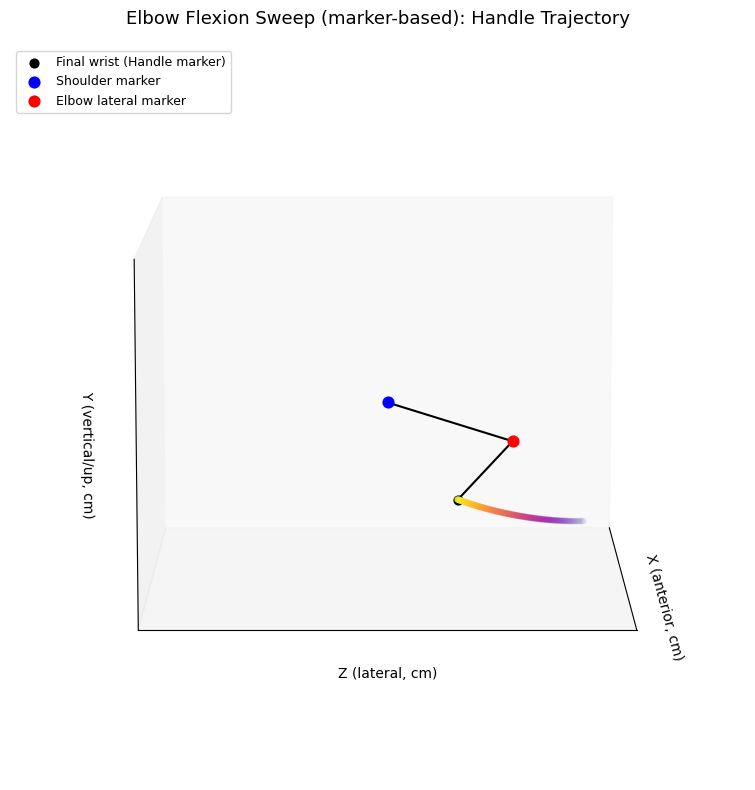

In [17]:
d = np.load(os.path.join(DATA_DIR, "elbow_sweep_markers.npz"))
times = d["times"]
shoulder = d["shoulder_xyz"]
elbow    = d["elbow_xyz"]
wrist    = d["wrist_xyz"]

elbow_c = (elbow - shoulder) * 100
wrist_c = (wrist - shoulder) * 100

def reorder(arr):
    return arr[:, [0, 2, 1]]  # X, Z, Y -> Y still maps to screen-vertical axis

endeffector_coords = reorder(wrist_c).T
elbow_coords = reorder(elbow_c).T

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(elev=10, azim=0)  # face-on to the Y-Z plane, matches confirmed horizontal sweep

cmap = matplotlib.colormaps["plasma"]
norm = Normalize(vmin=0, vmax=len(times))
alpha_values = np.linspace(0.2, 1, len(times))
colors = [cmap(norm(i)) for i in range(len(times))]
colors_with_alpha = [(r, g, b, a) for (r, g, b, _), a in zip(colors, alpha_values)]

ax.scatter(endeffector_coords[0], endeffector_coords[1], endeffector_coords[2],
           c=colors_with_alpha, s=15)
ax.scatter(endeffector_coords[0, -1], endeffector_coords[1, -1], endeffector_coords[2, -1],
           c='black', s=40, label='Final wrist (Handle marker)')

ax.scatter(0, 0, 0, c='blue', s=60, label='Shoulder marker')
ax.scatter(elbow_coords[0, -1], elbow_coords[1, -1], elbow_coords[2, -1],
           c='red', s=60, label='Elbow lateral marker')

ax.plot([0, elbow_coords[0, -1]], [0, elbow_coords[1, -1]], [0, elbow_coords[2, -1]], c='black')
ax.plot([elbow_coords[0, -1], endeffector_coords[0, -1]],
        [elbow_coords[1, -1], endeffector_coords[1, -1]],
        [elbow_coords[2, -1], endeffector_coords[2, -1]], c='black')

lim = 50
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
ax.set_xlabel("X (anterior, cm)")
ax.set_ylabel("Z (lateral, cm)")
ax.set_zlabel("Y (vertical/up, cm)")
ax.set_title("Elbow Flexion Sweep (marker-based): Handle Trajectory", fontsize=13, pad=15)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, linestyle=".", alpha=1)

ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/elbow_sweep_final.png", dpi=150)
print("saved")

## Sanity check
Confirms the sweep matches what was generated (45deg -> 90deg elbow flexion, shoulder held fixed) and that the wrist path extent looks anatomically reasonable.

In [16]:
bk = load_sto(f"{STO_DIR}/NewTest_BodyKinematics_pos_global.sto")
shoulder = bk[["humerus_X", "humerus_Y", "humerus_Z"]].to_numpy()
wrist    = bk[["hand_X",    "hand_Y",    "hand_Z"]].to_numpy()

print("humerus_Y (shoulder):", shoulder[0, 1], "->", shoulder[-1, 1])
print("hand_Y (wrist):", wrist[0, 1], "->", wrist[-1, 1])
print("Is hand above shoulder at final frame?", wrist[-1, 1] > shoulder[-1, 1])

humerus_Y (shoulder): -0.05288186 -> -0.05288186
hand_Y (wrist): -0.20646122 -> -0.16039809
Is hand above shoulder at final frame? False
